# Landsat 64x64 Patch Mosaic — Mask Comparison

Three mosaics of 100 patches from `s3://allotrope-raw-data-india/patches/landsat/train/intermediate/w64_h64_s32/`:
1. **Raw** — `pixels.npy`
2. **Validity masked** — `pixels.npy * validity_cube.npy`
3. **Custom quality masked** — `pixels.npy * pure_validity_mask.npy * custom_quality_mask.npy`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "exploratory_analyses" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import webdataset as wds
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

from app.utils.general_utils.shard_pipe_expression_builder import shard_pipe_expression_builder
from app.utils.image_transformation.image_cube_operations import ImageCubeOperations, CubeRepresentation

In [ ]:
SHARD_KEY = "patches/landsat/train/final/w126_h128_s64/"
BATCH_SIZE = 100
NROW = 10  # 10x10 grid

converter = ImageCubeOperations()

shard_url = shard_pipe_expression_builder(data_key=SHARD_KEY)
print(shard_url)

dataset = wds.WebDataset(shard_url, shardshuffle=100).decode()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=1)

batch = next(iter(dataloader))
print(f"Batch keys: {list(batch.keys())}")
print(f"pixels.npy shape: {batch['pixels.npy'].shape}")

Using device: mps
pipe: aws s3 cp s3://allotrope-raw-data-india/patches/landsat/train/final/w256_h256_s128/final_shard_{00000..00228}.tar -
Batch keys: ['__key__', '__url__', 'custom_quality_mask.npy', 'meta.json', 'pixels.npy', 'predicted_cloud_mask.npy', 'provider_cloud_presence.npy', 'provider_snow_presence.npy', 'provider_water_presence.npy', 'pure_validity_mask.npy', 'validity_cube.npy']
pixels.npy shape: torch.Size([100, 1, 256, 256])


download failed: s3://allotrope-raw-data-india/patches/landsat/train/final/w256_h256_s128/final_shard_00064.tar to - [Errno 32] Broken pipe


In [6]:
pixels = batch["pixels.npy"]
validity_cube = batch["validity_cube.npy"]
pure_validity = batch["pure_validity_mask.npy"]
custom_quality = batch["custom_quality_mask.npy"]

def to_2d_grid(tensor_batch, nrow=NROW):
    """Make a grid from (B, 1, H, W) tensors and return a 2D numpy array."""
    grid = make_grid(tensor_batch, nrow=nrow, padding=2)
    # make_grid outputs (3, H, W) — take channel 0
    bip = converter.convert_cube(grid, CubeRepresentation.BSQ, CubeRepresentation.BIP)
    return bip[:, :, 0]

# 1. Raw pixels
raw_2d = to_2d_grid(pixels)

# 2. pixels * validity_cube
validity_masked_2d = to_2d_grid(pixels * validity_cube)

# 3. pixels * pure_validity_mask * custom_quality_mask
quality_masked_2d = to_2d_grid(pixels * pure_validity * custom_quality)

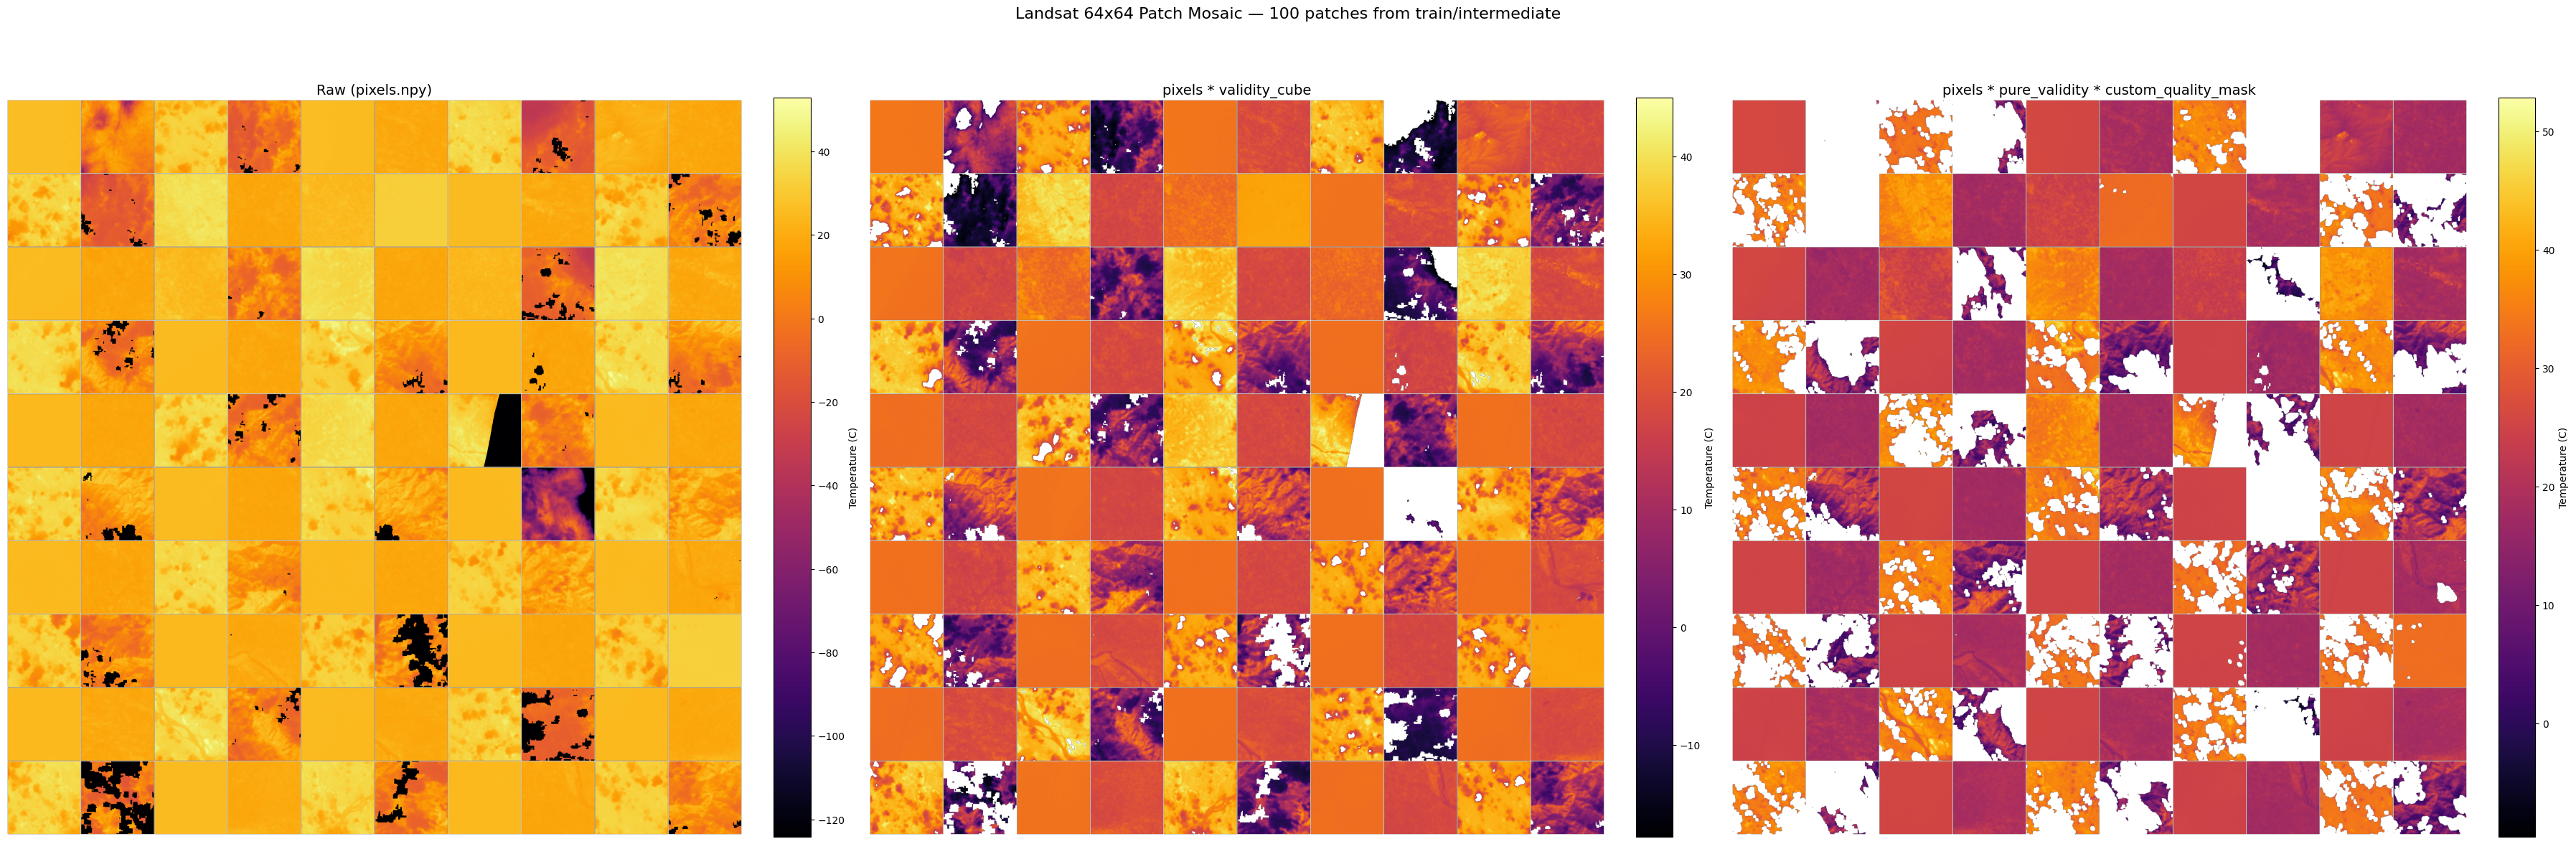

In [7]:
grids = [raw_2d, validity_masked_2d, quality_masked_2d]
vmin = min(g.min() for g in grids)
vmax = max(g.max() for g in grids)

fig, axes = plt.subplots(1, 3, figsize=(36, 12))

titles = [
    "Raw (pixels.npy)",
    "pixels * validity_cube",
    "pixels * pure_validity * custom_quality_mask",
]

for ax, title, grid in zip(axes, titles, grids):
    masked = np.ma.masked_where(grid == 0, grid)
    im = ax.imshow(masked, cmap="inferno")
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temperature (C)")

plt.suptitle(
    f"Landsat 64x64 Patch Mosaic — {BATCH_SIZE} patches from train/intermediate",
    fontsize=16, y=1.02,
)
plt.tight_layout()
plt.savefig("landsat_64_mask_comparison_mosaic.png", dpi=150, bbox_inches="tight")
plt.show()